# G-DAE training (local functions version)

This notebook trains a dense denoising autoencoder (G-DAE) for K2-18b-like
Sub-Neptune synthetic spectra.

In [1]:
from __future__ import annotations

import gc
import glob
import os
import re
import tempfile
import warnings
from typing import Dict, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pandexo.engine.justdoit as jdi

from sklearn.model_selection import train_test_split


def remove_warnings() -> None:
    """Silence DeprecationWarning to reduce notebook noise."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


remove_warnings()


In [2]:
waves = np.loadtxt("waves.txt", dtype=float)
n_points = int(len(waves))

indices = np.linspace(0, n_points - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)

waves = waves[indices]
wn_grid = np.sort(10000.0 / waves)

print("n_points:", n_points)
print("waves range [μm]:", float(waves.min()), "–", float(waves.max()))

n_points: 385
waves range [μm]: 0.698805 – 5.297569


In [3]:
def apply_contaminations_from_files(
    contamination_files: list[str],
    df: pd.DataFrame,
    n_points: int,
    include_no_contam: bool = False,
) -> pd.DataFrame:
    """
    Apply multiplicative stellar contamination ε(λ) from a list of text files.

    Parameters
    ----------
    contamination_files
        Paths to .txt files. Expected suffix pattern: fspot<val>_ffac<val>.txt
        Example: epsilon_T3400_fspot0.000_ffac0.000.txt
    df
        Input dataframe containing spectra in the last n_points columns.
    n_points
        Number of spectral columns at the end of df to contaminate.
    include_no_contam
        If True, prepend an explicit uncontaminated copy (f_spot=f_fac=0),
        and skip the (0,0) file if it exists to avoid duplication.

    Returns
    -------
    pd.DataFrame
        Concatenated dataframe with contamination cases. Adds columns:
        - f_spot, f_fac
        Also sets:
        - df_final.data   -> last n_points columns
        - df_final.params -> all other columns
    """
    df_list: list[pd.DataFrame] = []

    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        cols = ["f_spot", "f_fac"] + [
            col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_list.append(df_no_contam[cols])

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        contamination_data = np.loadtxt(file_path, ndmin=2)

        if contamination_data.shape[1] >= 2:
            contam_values = contamination_data[:, 1]
        else:
            contam_values = contamination_data.flatten()

        if len(contam_values) != n_points:
            raise ValueError(
                f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                f"does not match n_points ({n_points})."
            )

        # Match dataset wavelength ordering (your current convention).
        contam_values = contam_values[::-1]

        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        cols = ["f_spot", "f_fac"] + [
            col for col in df_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_list.append(df_contam[cols])

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


## Load base dataset and create a flat reference spectrum

We load `k2-18b_data.joblib`, fill NaNs in gas columns, and build a flat spectrum
sample with constant depth.

We keep `.data` (spectra) and `.params` (labels) consistent with the original layout.

In [4]:
k2_18b = joblib.load("specs/k2-18b_data.joblib")

gas_cols = ["atm CO2", "atm CH4", "atm H2O", "atm NH3"]
k2_18b[gas_cols] = k2_18b[gas_cols].fillna(0)

flat = k2_18b[
    (k2_18b["atm CO2"] == -10)
    & (k2_18b["atm CH4"] == 0)
    & (k2_18b["atm H2O"] == 0)
    & (k2_18b["atm NH3"] == 0)
].iloc[0:1].copy()

flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = 0.0023243496509944973

flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

print("k2_18b shape:", k2_18b.shape)
print("flat.data shape:", flat.data.shape)
print("flat.params shape:", flat.params.shape)


k2_18b shape: (22050, 407)
flat.data shape: (1, 385)
flat.params shape: (1, 22)


C:\Users\User\AppData\Local\Temp\ipykernel_26940\1297772740.py:16: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_26940\1297772740.py:17: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]


## Apply contaminations $\varepsilon(\lambda)$

In [5]:
contamination_files = sorted(glob.glob("TLS/epsilon_T*_fspot*_ffac*.txt"))
print("N contamination files found:", len(contamination_files))

k2_18b_contam = apply_contaminations_from_files(
    contamination_files,
    k2_18b,
    n_points=n_points,
)

flat_contam = apply_contaminations_from_files(
    contamination_files,
    flat,
    n_points=n_points,
)

print("k2_18b_contam:", k2_18b_contam.shape, "| data:", k2_18b_contam.data.shape)
print("flat_contam:", flat_contam.shape, "| data:", flat_contam.data.shape)


N contamination files found: 48


C:\Users\User\AppData\Local\Temp\ipykernel_26940\653889349.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_26940\653889349.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_26940\653889349.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

k2_18b_contam: (1058400, 409) | data: (1058400, 385)
flat_contam: (48, 409) | data: (48, 385)


In [6]:
def mult_df(df: pd.DataFrame, n_points: int, n_mult: int) -> pd.DataFrame:
    """
    Duplicate the dataframe (n_mult + 1) times and attach (f_spot, f_fac) = (0, 0).

    Returns a dataframe with .data and .params attributes, where the last n_points
    columns are considered spectra.
    """
    df_list: list[pd.DataFrame] = []

    for _ in range(int(n_mult) + 1):
        df_copy = df.copy()
        df_copy["f_spot"] = 0.0
        df_copy["f_fac"] = 0.0

        cols = ["f_spot", "f_fac"] + [
            col for col in df_copy.columns if col not in ["f_spot", "f_fac"]
        ]
        df_list.append(df_copy[cols])

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]
    return df_final


n_mult = int(len(contamination_files) - 1)

k2_18b_mult = mult_df(k2_18b, n_points=n_points, n_mult=n_mult)
flat_mult = mult_df(flat, n_points=n_points, n_mult=n_mult)

print("k2_18b_mult:", k2_18b_mult.shape, "| data:", k2_18b_mult.data.shape)
print("flat_mult:", flat_mult.shape, "| data:", flat_mult.data.shape)


C:\Users\User\AppData\Local\Temp\ipykernel_26940\1670612315.py:21: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_26940\1670612315.py:22: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]


k2_18b_mult: (1058400, 409) | data: (1058400, 385)
flat_mult: (48, 409) | data: (48, 385)


C:\Users\User\AppData\Local\Temp\ipykernel_26940\1670612315.py:21: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_26940\1670612315.py:22: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]


### Quick plot: contaminated flat vs clean flat

This is a sanity check that:
- contamination modifies the flat spectrum as expected
- the clean flat reference stays constant


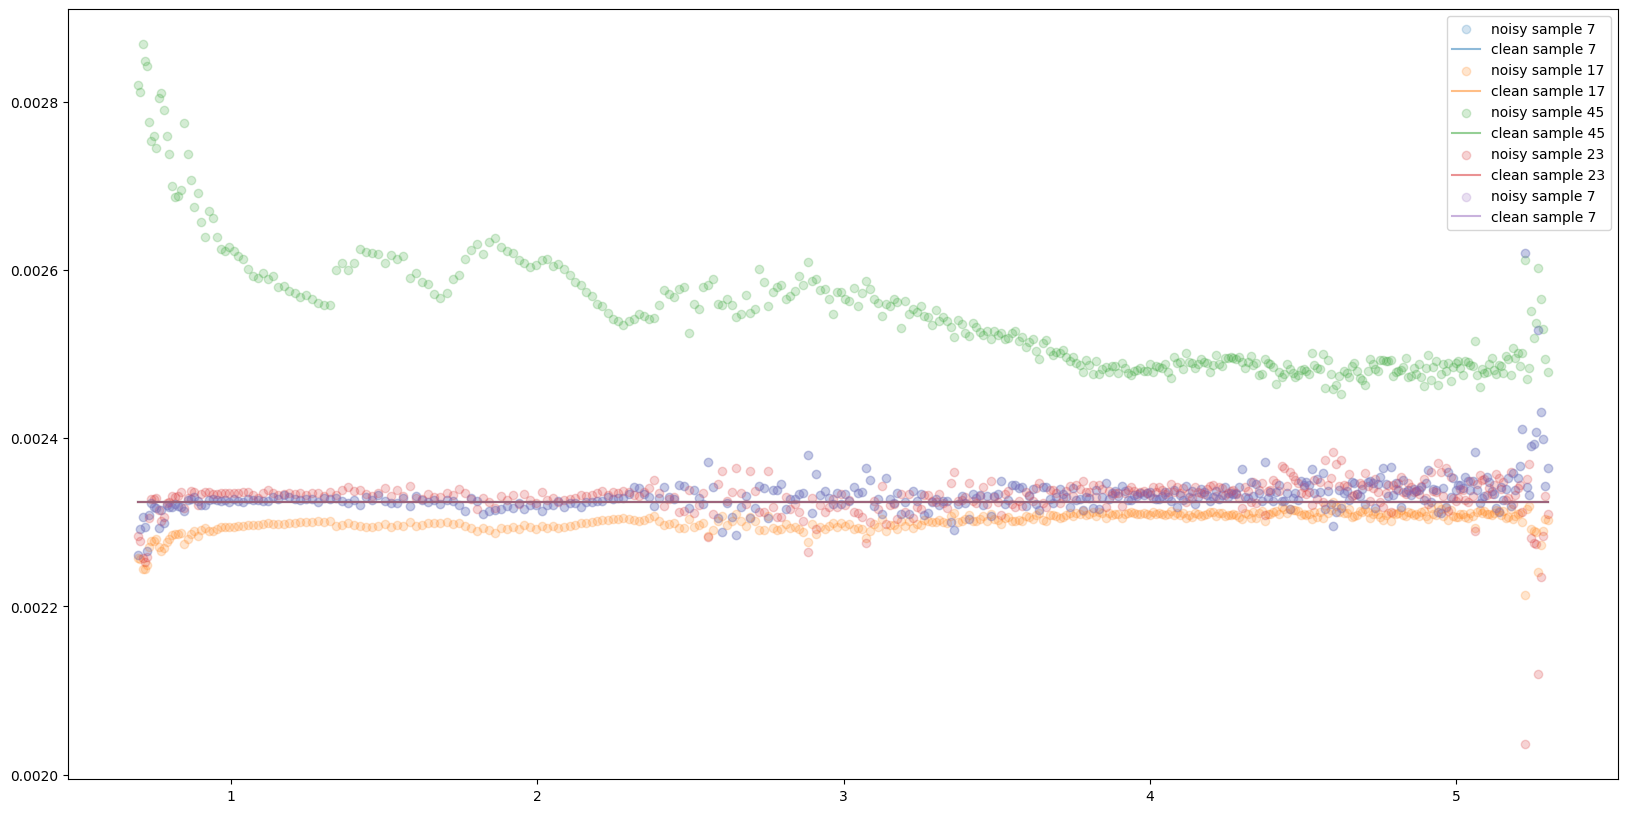

In [10]:
plt.figure(figsize=(20, 10))

columns = flat_contam.columns[-n_points:]
for _ in range(5):
    idx = np.random.randint(0, flat_contam.shape[0])
    plt.scatter(columns, flat_contam.iloc[idx, -n_points:],
    alpha=0.2, label=f"noisy sample {idx}")
    plt.plot(flat_mult.iloc[idx, -n_points:], alpha=0.5, 
    label=f"clean sample {idx}")

plt.legend(loc = "upper right")
plt.show()


## PandExo: instrument noise $\sigma_{inst}(\lambda)$ for K2-18 / NIRSpec Prism

We generate $\sigma_{inst}(\lambda)$ using a flat spectrum and PandExo, for transit counts:
T ∈ {1, 2, 4} at fixed T* = 3500 K.

Important details:
- PandExo returns (waves_trim, errors_trim).
- We reverse σ_inst with `[::-1]` to match the dataset wavelength ordering,
  consistent with the contamination ordering.


In [11]:
MAG_J_K218 = 9.763
TSTAR_K218 = 3500.0
LOGG_K218 = 4.6
MET_K218 = 0.0
TTRANS_H_K218 = 2.682

DEPTH_K218 = 0.0023243496509944973


def get_k218_prism_noise_flat(
    wl_grid_um: np.ndarray,
    depth_rp2_rs2: float = DEPTH_K218,
    n_transits: int = 10,
    T_s: float = TSTAR_K218,
    transit_duration_hours: float = TTRANS_H_K218,
    plot: bool = False,
    cut_first: int = 20,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return a representative JWST/NIRSpec Prism instrument noise curve σ_inst(λ)
    using PandExo for a flat transit depth spectrum.

    Returns
    -------
    waves_trim, errors_trim
        Trimmed wavelength grid (μm) and error_w_floor (same length).
    """
    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    tmp_path: str | None = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        exo = jdi.load_exo_dict()

        transit_duration_sec = float(transit_duration_hours) * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        exo["observation"].update(
            {
                "sat_level": 80,
                "sat_unit": "%",
                "baseline_unit": "total",
                "baseline": baseline_sec,
                "noise_floor": 0,
                "noccultations": int(n_transits),
            }
        )

        exo["star"].update(
            {
                "type": "phoenix",
                "mag": MAG_J_K218,
                "ref_wave": 1.25,
                "temp": float(T_s),
                "metal": MET_K218,
                "logg": LOGG_K218,
            }
        )

        exo["planet"].update(
            {
                "type": "user",
                "w_unit": "um",
                "f_unit": "rp^2/r*^2",
                "transit_duration": transit_duration_sec,
                "td_unit": "s",
                "exopath": tmp_path,
            }
        )

        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({"subarray": "sub512", "ngroup": 6})

        results = jdi.run_pandexo(exo, inst)

        waves_full = results["FinalSpectrum"]["wave"]
        flux_full = results["FinalSpectrum"]["spectrum"]
        errors_full = results["FinalSpectrum"]["error_w_floor"]

        if cut_first > 0:
            waves_trim = waves_full[cut_first:]
            flux_trim = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim = waves_full
            flux_trim = flux_full
            errors_trim = errors_full

        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim,
                flux_trim,
                yerr=errors_trim,
                fmt="o",
                ms=4,
                elinewidth=1,
                capsize=2,
            )
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Transit depth (Rp/R*)²")
            plt.title(f"PandExo K2-18 — {n_transits} transits, T*={T_s:.0f} K")
            plt.tight_layout()
            plt.show()

    finally:
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim


In [12]:
wl_base = np.linspace(0.6, 5.3, 1000)

sigma_by_T: Dict[int, np.ndarray] = {}
for T in [1, 2, 4]:
    _, sigma_T = get_k218_prism_noise_flat(
        wl_grid_um=wl_base,
        n_transits=T,
        T_s=3500.0,
        plot=False,
        cut_first=18,
    )
    sigma_by_T[T] = sigma_T[::-1]

n_points = int(sigma_by_T[1].shape[0])

assert k2_18b_mult.data.shape[1] == n_points
assert k2_18b_contam.data.shape[1] == n_points
assert flat_mult.data.shape[1] == n_points
assert flat_contam.data.shape[1] == n_points

print("n_points (final, from σ_inst):", n_points)


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
n_points (final, from σ_inst): 385


In [13]:
def generate_df_with_noise_std(
    df: pd.DataFrame,
    n_repeat: int,
    noise_std: float | np.ndarray,
    seed: int | None = None,
) -> pd.DataFrame:
    """
    Replicate spectra and apply Gaussian noise.

    Parameters
    ----------
    df
        Must have df.params and df.data attributes.
    n_repeat
        Number of repetitions per spectrum.
    noise_std
        - scalar: same sigma everywhere
        - 1D length N_spectra: sigma per spectrum (copied to all wavelengths)
        - 1D length N_wavelengths: sigma per wavelength (same vector for all rows)
    seed
        Random seed.

    Returns
    -------
    pd.DataFrame
        Dataframe with df_final.params and df_final.data attributes.
    """
    if not hasattr(df, "params") or not hasattr(df, "data"):
        raise ValueError("The input DataFrame must have 'params' and 'data' attributes.")

    df_params = df.params
    df_spectra = df.data

    if seed is not None:
        np.random.seed(int(seed))

    n_spec, n_wl = df_spectra.shape

    df_spectra_rep = pd.DataFrame(
        np.repeat(df_spectra.values, int(n_repeat), axis=0),
        columns=df_spectra.columns,
    )

    if isinstance(noise_std, (int, float)):
        if float(noise_std) < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_replicated = np.full(df_spectra_rep.shape, float(noise_std))
        noise_std_for_params = np.full(n_spec * int(n_repeat), float(noise_std))

    else:
        noise_array = np.asarray(noise_std, dtype=float)
        if noise_array.ndim != 1:
            raise ValueError("noise_std must be 1D if array-like.")
        if np.any(noise_array < 0):
            raise ValueError("All values in noise_std must be non-negative.")

        if len(noise_array) == n_spec:
            base = noise_array[:, np.newaxis]
            base = np.repeat(base, int(n_repeat), axis=0)
            noise_replicated = np.tile(base, (1, n_wl))
            noise_std_for_params = np.repeat(noise_array, int(n_repeat))

        elif len(noise_array) == n_wl:
            noise_replicated = np.tile(noise_array, (n_spec * int(n_repeat), 1))
            noise_std_for_params = np.full(n_spec * int(n_repeat), float(noise_array.mean()))

        else:
            raise ValueError(
                "If noise_std is array-like, its length must be either "
                "N_spectra or N_wavelengths."
            )

    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_replicated,
        size=df_spectra_rep.shape,
    )
    df_spectra_rep = df_spectra_rep + gaussian_noise

    df_params_rep = pd.DataFrame(
        np.repeat(df_params.values, int(n_repeat), axis=0),
        columns=df_params.columns,
    )
    df_params_rep.insert(0, "noise_std", noise_std_for_params)
    df_params_rep.insert(1, "n_repeat", int(n_repeat))

    df_final = pd.concat(
        [df_params_rep.reset_index(drop=True), df_spectra_rep.reset_index(drop=True)],
        axis=1,
    )

    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -df_spectra_rep.shape[1]:]
    df_final.params = df_final.iloc[:, : df_params_rep.shape[1]]
    warnings.filterwarnings("default")

    return df_final


## Build dataset blocks per transit label T

For each T label:
- NOISY block: contaminated spectra (+ σ_inst noise if enabled)
- CLEAN block: replicated clean spectra (no noise)

Then both noisy and clean blocks are normalized row-wise (min–max).


In [14]:
def build_block_for_T(
    T_label: float,
    sigma_T: np.ndarray | None,
    n_repeat_main: int,
    flat_factor: int,
    add_instrument_noise: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build (X_noisy, X_clean, T_vec) for one transit label.

    The normalization is row-wise min–max for noisy and clean independently,
    matching the current pipeline.
    """
    n_main = int(n_repeat_main)
    n_flat = int(n_repeat_main * flat_factor)

    if add_instrument_noise:
        noise_std_contam = sigma_T
    else:
        noise_std_contam = 0.0

    df_noisy_main = generate_df_with_noise_std(
        df=k2_18b_contam,
        n_repeat=n_main,
        noise_std=noise_std_contam,
    )
    df_noisy_flat = generate_df_with_noise_std(
        df=flat_contam,
        n_repeat=n_flat,
        noise_std=noise_std_contam,
    )

    n_param_cols = df_noisy_main.params.shape[1]
    n_spec_cols = df_noisy_main.data.shape[1]

    df_noisy_all = pd.concat([df_noisy_main, df_noisy_flat], ignore_index=True)
    df_noisy_all.params = df_noisy_all.iloc[:, :n_param_cols]
    df_noisy_all.data = df_noisy_all.iloc[:, -n_spec_cols:]

    df_clean_main = generate_df_with_noise_std(
        df=k2_18b_mult,
        n_repeat=n_main,
        noise_std=0.0,
    )
    df_clean_flat = generate_df_with_noise_std(
        df=flat_mult,
        n_repeat=n_flat,
        noise_std=0.0,
    )

    n_param_cols_clean = df_clean_main.params.shape[1]
    n_spec_cols_clean = df_clean_main.data.shape[1]

    df_clean_all = pd.concat([df_clean_main, df_clean_flat], ignore_index=True)
    df_clean_all.params = df_clean_all.iloc[:, :n_param_cols_clean]
    df_clean_all.data = df_clean_all.iloc[:, -n_spec_cols_clean:]

    assert df_noisy_all.shape[0] == df_clean_all.shape[0]
    assert df_noisy_all.data.shape[1] == df_clean_all.data.shape[1]

    # NOISY normalization
    spec_noisy_df = df_noisy_all.data.copy()
    min_by_row_n = spec_noisy_df.min(axis=1)
    max_by_row_n = spec_noisy_df.max(axis=1)
    range_by_row_n = max_by_row_n - min_by_row_n

    spec_noisy_norm = spec_noisy_df.sub(min_by_row_n, axis=0).div(range_by_row_n, axis=0)
    mask_n = range_by_row_n == 0
    if mask_n.any():
        spec_noisy_norm.loc[mask_n, :] = 0

    spec_noisy = spec_noisy_norm.values.astype("float32")

    # CLEAN normalization
    spec_clean_df = df_clean_all.data.copy()
    min_by_row_c = spec_clean_df.min(axis=1)
    max_by_row_c = spec_clean_df.max(axis=1)
    range_by_row_c = max_by_row_c - min_by_row_c

    spec_clean_norm = spec_clean_df.sub(min_by_row_c, axis=0).div(range_by_row_c, axis=0)
    mask_c = range_by_row_c == 0
    if mask_c.any():
        spec_clean_norm.loc[mask_c, :] = 0

    spec_clean = spec_clean_norm.values.astype("float32")

    T_vec = np.full(spec_noisy.shape[0], T_label, dtype=float)

    del (
        df_noisy_main,
        df_noisy_flat,
        df_noisy_all,
        df_clean_main,
        df_clean_flat,
        df_clean_all,
        spec_noisy_df,
        spec_clean_df,
        spec_noisy_norm,
        spec_clean_norm,
    )
    gc.collect()

    return spec_noisy, spec_clean, T_vec


## Assemble final arrays and save dataset NPZ

We build blocks for:
- T ∈ {1,2,4} with instrument noise
- T = NaN without instrument noise (contamination-only baseline)

Then we concatenate into:
- X_noisy, X_clean, T_labels
and save `k218_autoencoder_dataset.npz`.


In [ ]:
""" X_noisy_list = []
X_clean_list = []
T_labels_list = []

for T_val in [1, 2, 4]:
    Xn, Xc, Tl = build_block_for_T(
        T_label=float(T_val),
        sigma_T=sigma_by_T[T_val],
        n_repeat_main=5,
        flat_factor=100,
        add_instrument_noise=True,
    )
    X_noisy_list.append(Xn)
    X_clean_list.append(Xc)
    T_labels_list.append(Tl)

Xn, Xc, Tl = build_block_for_T(
    T_label=np.nan,
    sigma_T=None,
    n_repeat_main=7,
    flat_factor=70,
    add_instrument_noise=False,
)
X_noisy_list.append(Xn)
X_clean_list.append(Xc)
T_labels_list.append(Tl)

X_noisy = np.vstack(X_noisy_list).astype("float32")
X_clean = np.vstack(X_clean_list).astype("float32")
T_labels = np.concatenate(T_labels_list).astype(float)

print("Final shapes:", X_noisy.shape, X_clean.shape, T_labels.shape)
assert X_noisy.shape == X_clean.shape

np.savez_compressed(
    "k218_autoencoder_dataset.npz",
    X_noisy=X_noisy,
    X_clean=X_clean,
    T_labels=T_labels,
)
print("Saved: k218_autoencoder_dataset.npz")
 """

In [15]:
# load k218_autoencoder_dataset.npz
X_noisy, X_clean, T_label = np.load("k218_autoencoder_dataset.npz").values()

## Train/test split

In [16]:
test_size = 0.2

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_clean,
    test_size=test_size,
    random_state=42,
)

del X_noisy, X_clean
gc.collect()

print("Train:", X_train_noisy.shape, X_train_clean.shape)
print("Test :", X_test_noisy.shape, X_test_clean.shape)


Train: (6234752, 385) (6234752, 385)
Test : (1558688, 385) (1558688, 385)


# G-DAE Architecture

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

input_dim = int(X_train_noisy.shape[1])
l2_lambda = 1e-7

input_spectrum = keras.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)

# Decoder
decoded = layers.Dense(300, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(300, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation="swish", 
            kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)

output_spectrum = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_spectrum, outputs=output_spectrum)

optimizer = Adam(learning_rate=1e-5)
autoencoder.compile(optimizer=optimizer, loss="mae")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 385)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 385)            │       197,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,673 (7.72 MB)

 Trainable params: 2,024,673 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 841s 9ms/step - loss: 0.1093 - val_loss: 0.0544
Epoch 2/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 838s 9ms/step - loss: 0.0672 - val_loss: 0.0396
Epoch 3/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 844s 9ms/step - loss: 0.0538 - val_loss: 0.0318
Epoch 4/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 846s 9ms/step - loss: 0.0451 - val_loss: 0.0285
Epoch 5/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 848s 9ms/step - loss: 0.0423 - val_loss: 0.0259
Epoch 6/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 850s 9ms/step - loss: 0.0404 - val_loss: 0.0243
Epoch 7/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 846s 9ms/step - loss: 0.0390 - val_loss: 0.0229
Epoch 8/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 847s 9ms/step - loss: 0.0378 - val_loss: 0.0221
Epoch 9/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 848s 9ms/step - loss: 0.0369 - val_loss: 0.0212
Epoch 10/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 849s 9ms/step - loss: 0.0360 - val_loss: 0.0211
Epoch 11/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 850s 9ms/step - loss: 0

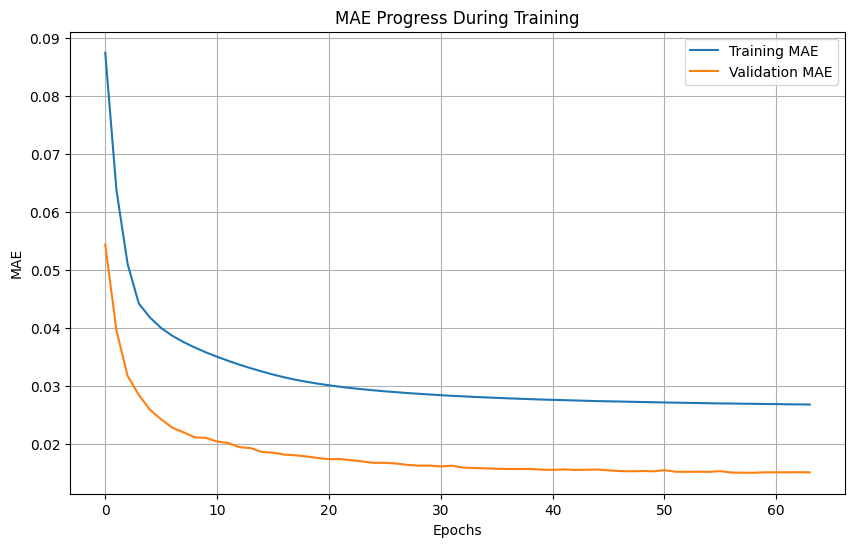

48709/48709 ━━━━━━━━━━━━━━━━━━━━ 306s 6ms/step


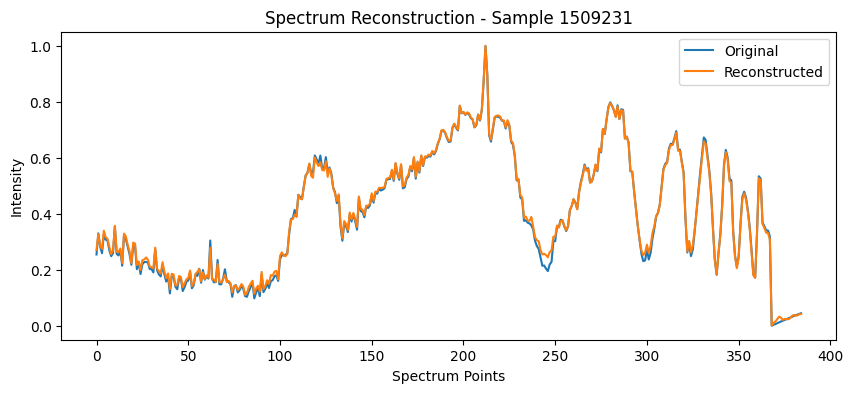

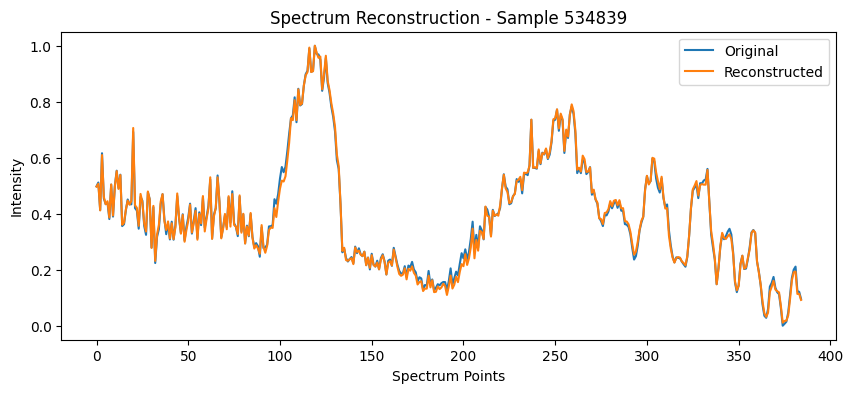

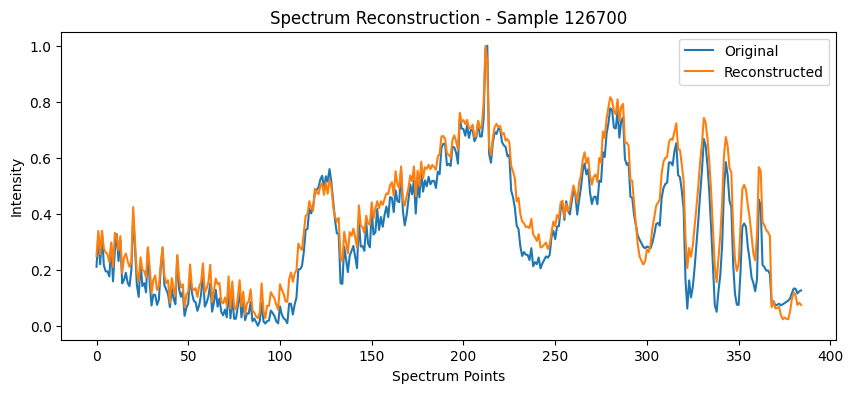

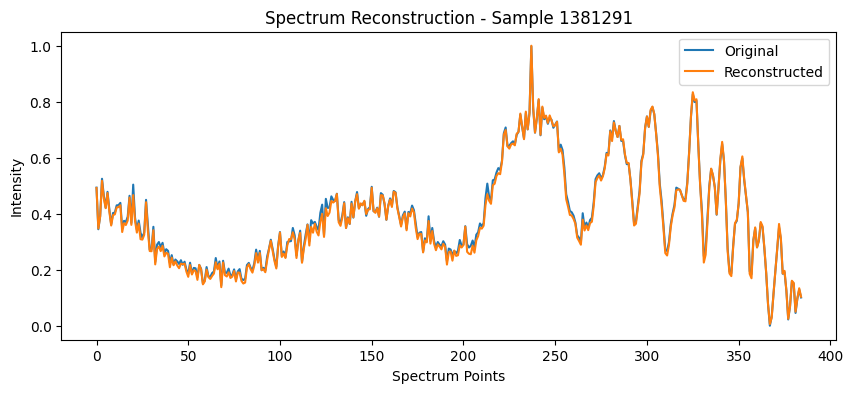

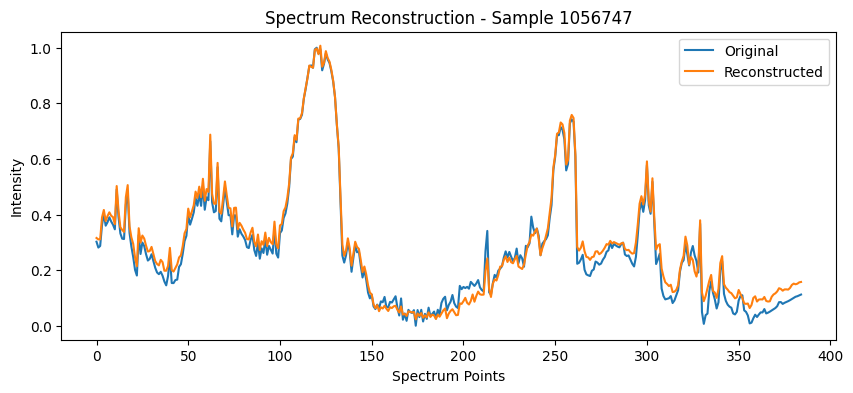

In [ ]:
""" # Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train_clean,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_clean),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
)

# Save the trained model
autoencoder.save("AE.keras")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.title("MAE Progress During Training")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# Predict reconstructed spectra on test data
decoded_spectra = autoencoder.predict(X_test_noisy)

# Visualize a few reconstructions
num_samples = 5  # Number of samples to visualize
indices = np.random.choice(len(X_test_noisy), num_samples, replace=False)

for idx in indices:
    plt.figure(figsize=(10, 4))
    plt.plot(X_test_clean[idx].flatten(), label="Original")
    plt.plot(decoded_spectra[idx].flatten(), label="Reconstructed")
    plt.xlabel("Spectrum Points")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum Reconstruction - Sample {idx}")
    plt.legend()
    plt.show()
 """

## Evaluation metrics (MAE / MSE / R²)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras


autoencoder = keras.models.load_model("AE.keras")
X_reconstructed = autoencoder.predict(X_test_noisy)

# Compute evaluation metrics on the test set
mae = mean_absolute_error(X_test_clean, X_reconstructed)
print(f"Mean Absolute Error (MAE): {mae:.6f}")

mse = mean_squared_error(X_test_clean, X_reconstructed)
print(f"Mean Squared Error (MSE): {mse:.6f}")

r2 = r2_score(X_test_clean, X_reconstructed)
print(f"Coefficient of Determination (R²): {r2:.6f}")

48709/48709 ━━━━━━━━━━━━━━━━━━━━ 312s 6ms/step
Mean Absolute Error (MAE): 0.014487
Mean Squared Error (MSE): 0.000534
Coefficient of Determination (R²): 0.975199
